Experiment 1 a.

In [2]:
!pip install torch torchvision --quiet


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torch.cuda.amp import autocast, GradScaler
import pandas as pd
from tqdm import tqdm


In [5]:
torch.manual_seed(42)
torch.cuda.manual_seed_all(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)


Using device: cpu


In [6]:
from torch.utils.data import DataLoader, random_split, Subset

def get_dataloaders(dataset_name, batch_size, pin_memory, max_samples=15000):
    transform = transforms.Compose([
        transforms.Resize(224),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
    ])

    if dataset_name == "MNIST":
        full_dataset = datasets.MNIST("./data", train=True, download=True, transform=transform)
    else:
        full_dataset = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)

    # 🔥 Reduce datapoints here
    reduced_len = min(max_samples, len(full_dataset))
    reduced_dataset = Subset(full_dataset, range(reduced_len))

    total = len(reduced_dataset)
    train_len = int(0.7 * total)
    val_len   = int(0.1 * total)
    test_len  = total - train_len - val_len

    train_ds, val_ds, test_ds = random_split(
        reduced_dataset, [train_len, val_len, test_len]
    )

    train_loader = DataLoader(
        train_ds, batch_size=batch_size, shuffle=True, pin_memory=pin_memory
    )
    val_loader = DataLoader(
        val_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory
    )
    test_loader = DataLoader(
        test_ds, batch_size=batch_size, shuffle=False, pin_memory=pin_memory
    )

    return train_loader, val_loader, test_loader


In [7]:
def get_model(model_name):
    if model_name == "resnet18":
        model = models.resnet18(pretrained=False)
    elif model_name == "resnet50":
        model = models.resnet50(pretrained=False)
    else:
        raise ValueError("Invalid model name")

    model.fc = nn.Linear(model.fc.in_features, 10)
    return model


In [8]:
def train_model(model, train_loader, optimizer, criterion, epochs):
    model.train()
    scaler = GradScaler()

    for epoch in range(epochs):
        running_loss = 0.0
        loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{epochs}]")

        for images, labels in loop:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            running_loss += loss.item()
            loop.set_postfix(loss=loss.item())


In [9]:
def evaluate(model, test_loader):
    model.eval()
    correct, total = 0, 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (preds == labels).sum().item()

    return 100 * correct / total


In [10]:
def run_experiments(dataset_name, epochs):
    results = []

    configs = [
        (16, "SGD", 0.001),
        (16, "SGD", 0.0001),
        (16, "Adam", 0.001),
        (16, "Adam", 0.0001),
        (32, "SGD", 0.001),
        (32, "Adam", 0.0001),
    ]

    for batch_size, opt_name, lr in configs:
        for model_name in ["resnet18", "resnet50"]:
            print(f"\nDataset={dataset_name} | Model={model_name} | "
                  f"Batch={batch_size} | Opt={opt_name} | LR={lr}")

            train_loader, _, test_loader = get_dataloaders(
                dataset_name, batch_size, pin_memory=True
            )

            model = get_model(model_name).to(device)
            criterion = nn.CrossEntropyLoss()

            if opt_name == "SGD":
                optimizer = optim.SGD(model.parameters(), lr=lr, momentum=0.9)
            else:
                optimizer = optim.Adam(model.parameters(), lr=lr)

            train_model(model, train_loader, optimizer, criterion, epochs)
            acc = evaluate(model, test_loader)

            results.append({
                "Dataset": dataset_name,
                "Model": model_name,
                "BatchSize": batch_size,
                "Optimizer": opt_name,
                "LR": lr,
                "Epochs": epochs,
                "Test Accuracy (%)": round(acc, 2)
            })

            pd.DataFrame(results).to_csv("Q1a_partial_results.csv", index=False)


            print("Test Accuracy:", acc)

    return pd.DataFrame(results)


In [ ]:
df_10 = run_experiments("MNIST", epochs=8)


Dataset=MNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.001


/tmp/ipython-input-1744925364.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch [1/8]:   0%|          | 0/657 [00:00<?, ?it/s]/tmp/ipython-input-1744925364.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [8/8]: 100%|██████████| 657/657 [00:33<00:00, 19.49it/s, loss=0.00724]


Test Accuracy: 99.0

Dataset=MNIST | Model=resnet50 | Batch=16 | Opt=SGD | LR=0.001


Epoch [8/8]: 100%|██████████| 657/657 [00:59<00:00, 11.01it/s, loss=0.00294]


Test Accuracy: 98.06666666666666

Dataset=MNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.0001


...

Epoch [8/8]: 100%|██████████| 329/329 [00:55<00:00,  5.89it/s, loss=3.83]


Test Accuracy: 97.93333333333334

Dataset=MNIST | Model=resnet18 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [8/8]: 100%|██████████| 329/329 [00:30<00:00, 10.67it/s, loss=0.00333]


Test Accuracy: 95.03333333333333

Dataset=MNIST | Model=resnet50 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [2/8]:  99%|█████████▉| 327/329 [00:59<00:00,  4.76it/s, loss=0.0384]

In [10]:
df_10_f = run_experiments("FashionMNIST", epochs=8)


Dataset=FashionMNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.001


100%|██████████| 26.4M/26.4M [00:02<00:00, 11.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 211kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.95MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 29.8MB/s]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
/tmp/ipython-input-1744925364.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch [1/8]:   0%|          | 0/657 [00:00<?, ?it/s]/tmp/ipython-input-1744925364.py:14: Futu

Test Accuracy: 87.76666666666667

Dataset=FashionMNIST | Model=resnet50 | Batch=16 | Opt=SGD | LR=0.001


Epoch [8/8]: 100%|██████████| 657/657 [00:58<00:00, 11.22it/s, loss=0.192]


Test Accuracy: 86.76666666666667

Dataset=FashionMNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.0001


...

Test Accuracy: 82.86666666666666

Dataset=FashionMNIST | Model=resnet18 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [8/8]: 100%|██████████| 329/329 [00:30<00:00, 10.77it/s, loss=0.0162]


Test Accuracy: 88.43333333333334

Dataset=FashionMNIST | Model=resnet50 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [8/8]: 100%|██████████| 329/329 [00:57<00:00,  5.73it/s, loss=1.1]


Test Accuracy: 86.2


In [ ]:
df_20 = run_experiments("MNIST", epochs=1)


Dataset=MNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.001


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.0MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 482kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.50MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.98MB/s]
/tmp/ipython-input-1744925364.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch [1/1]:   0%|          | 0/2625 [00:00<?, ?it/s]/tmp/ipython-input-1744925364.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [1/1]: 100%|██████████| 2625/2625 [02:10<00:00, 20.14it/s, loss=0.0153]


Test Accuracy: 97.53333333333333

Dataset=MNIST | Model=resnet50 | Batch=16 | Opt=SGD | LR=0.001


Epoch [1/1]: 100%|██████████| 2625/2625 [03:54<00:00, 11.22it/s, loss=0.141]


Test Accuracy: 97.49166666666666

Dataset=MNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.0001


...

Test Accuracy: 96.26666666666667

Dataset=MNIST | Model=resnet18 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [1/1]: 100%|██████████| 1313/1313 [02:01<00:00, 10.84it/s, loss=0.00781]


Test Accuracy: 97.85833333333333

Dataset=MNIST | Model=resnet50 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [1/1]: 100%|██████████| 1313/1313 [03:48<00:00,  5.75it/s, loss=0.0837]


Test Accuracy: 97.925


In [ ]:
df_20_f = run_experiments("FashionMNIST", epochs=1)


Dataset=FashionMNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.001


/tmp/ipython-input-1744925364.py:3: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
Epoch [1/1]:   0%|          | 0/2625 [00:00<?, ?it/s]/tmp/ipython-input-1744925364.py:14: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
Epoch [1/1]: 100%|██████████| 2625/2625 [02:08<00:00, 20.44it/s, loss=0.432]


Test Accuracy: 82.75833333333334

Dataset=FashionMNIST | Model=resnet50 | Batch=16 | Opt=SGD | LR=0.001


Epoch [1/1]: 100%|██████████| 2625/2625 [03:52<00:00, 11.30it/s, loss=0.503]


Test Accuracy: 82.01666666666667

Dataset=FashionMNIST | Model=resnet18 | Batch=16 | Opt=SGD | LR=0.0001


...

Test Accuracy: 82.44166666666666

Dataset=FashionMNIST | Model=resnet18 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [1/1]: 100%|██████████| 1313/1313 [02:01<00:00, 10.83it/s, loss=0.269]


Test Accuracy: 88.375

Dataset=FashionMNIST | Model=resnet50 | Batch=32 | Opt=Adam | LR=0.0001


Epoch [1/1]: 100%|██████████| 1313/1313 [03:49<00:00,  5.73it/s, loss=0.325]


Test Accuracy: 87.725


Experment 1 b.

In [ ]:
import time
import numpy as np
import pandas as pd
from torchvision import datasets, transforms
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


In [ ]:
def load_svm_dataset(dataset_name, train_samples=10000, test_samples=2000):
    transform = transforms.ToTensor()

    if dataset_name == "MNIST":
        train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)
    else:
        train_ds = datasets.FashionMNIST("./data", train=True, download=True, transform=transform)
        test_ds  = datasets.FashionMNIST("./data", train=False, download=True, transform=transform)

    X_train = train_ds.data[:train_samples].view(train_samples, -1).numpy() / 255.0
    y_train = train_ds.targets[:train_samples].numpy()

    X_test = test_ds.data[:test_samples].view(test_samples, -1).numpy() / 255.0
    y_test = test_ds.targets[:test_samples].numpy()

    return X_train, y_train, X_test, y_test


In [ ]:
def train_evaluate_svm(X_train, y_train, X_test, y_test, kernel, C, degree=None):
    if kernel == "poly":
        clf = SVC(kernel=kernel, C=C, degree=degree)
    else:
        clf = SVC(kernel=kernel, C=C, gamma="scale")

    start_time = time.time()
    clf.fit(X_train, y_train)
    end_time = time.time()

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred) * 100
    train_time_ms = (end_time - start_time) * 1000

    return round(acc, 2), round(train_time_ms, 2)


In [ ]:
results = []

configs = [
    ("rbf", 1.0, None),
    ("rbf", 10.0, None),
    ("poly", 1.0, 2),
    ("poly", 1.0, 3),
]

for dataset in ["MNIST", "FashionMNIST"]:
    print(f"\nRunning SVM on {dataset}")
    X_train, y_train, X_test, y_test = load_svm_dataset(dataset)

    for kernel, C, degree in configs:
        print(f"Kernel={kernel}, C={C}, Degree={degree}")

        acc, time_ms = train_evaluate_svm(
            X_train, y_train, X_test, y_test,
            kernel=kernel,
            C=C,
            degree=degree
        )

        results.append({
            "Dataset": dataset,
            "Kernel": kernel,
            "C": C,
            "Degree": degree,
            "Test Accuracy (%)": acc,
            "Training Time (ms)": time_ms
        })

        print(f"Accuracy={acc}%, Time={time_ms} ms")



Running SVM on MNIST
Kernel=rbf, C=1.0, Degree=None
Accuracy=94.45%, Time=13825.66 ms
Kernel=rbf, C=10.0, Degree=None
Accuracy=95.55%, Time=7533.72 ms
Kernel=poly, C=1.0, Degree=2
Accuracy=94.15%, Time=6714.92 ms
Kernel=poly, C=1.0, Degree=3
Accuracy=93.4%, Time=7622.94 ms

Running SVM on FashionMNIST
Kernel=rbf, C=1.0, Degree=None
Accuracy=86.0%, Time=7736.48 ms
Kernel=rbf, C=10.0, Degree=None
Accuracy=87.35%, Time=6830.12 ms
Kernel=poly, C=1.0, Degree=2
Accuracy=84.75%, Time=6979.44 ms
Kernel=poly, C=1.0, Degree=3
Accuracy=82.8%, Time=8153.68 ms


In [ ]:
df_svm = pd.DataFrame(results)
df_svm.to_csv("Q1b_SVM_results.csv", index=False)
df_svm


,Dataset,Kernel,C,Degree,Test Accuracy (%),Training Time (ms)
0,MNIST,rbf,1.0,NaN,94.45,13825.66
1,MNIST,rbf,10.0,NaN,95.55,7533.72
2,MNIST,poly,1.0,2.0,94.15,6714.92
3,MNIST,poly,1.0,3.0,93.40,7622.94
4,FashionMNIST,rbf,1.0,NaN,86.00,7736.48
5,FashionMNIST,rbf,10.0,NaN,87.35,6830.12
6,FashionMNIST,poly,1.0,2.0,84.75,6979.44
7,FashionMNIST,poly,1.0,3.0,82.80,8153.68


In [ ]:
!pip install fvcore


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for fvcore: filename=fvcore-0.1.5.post20221221-py3-none-any.whl size=61397 sha256=2c284b3cecb71205219fb2ed7261f9711ff9b3f5d74544924c56ecde106079b4
  Stored in directory: /root/.cache/pip/wheels/ed/9f/a5/e4f5b27454ccd4596bd8b62432c7d6b1ca9fa22aef9d70a16a
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=ea2879089faa7d0ddee363e241459a2715bd178a66904883ac4aeba9d838140e
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built fvcore iopath


Result 1


In [15]:
train_losses = [
    0.745,
    0.679,
    0.106,
    1.87,
    0.0117,
    0.0282,
    0.0136,
    0.00724
]

epochs = [1, 2, 3, 4, 5, 6, 7, 8]


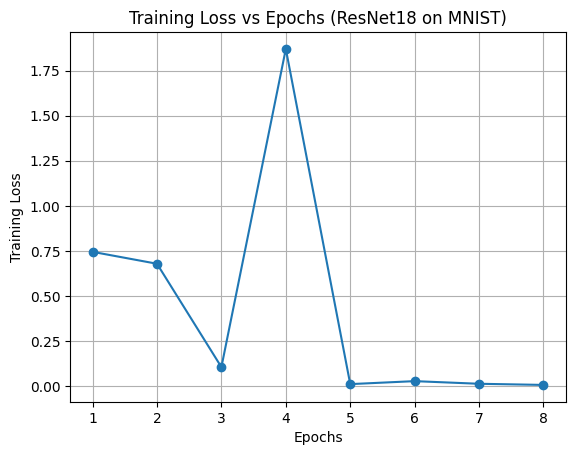

In [16]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epochs, train_losses, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs (ResNet18 on MNIST)")
plt.grid(True)
plt.show()


Result 2

In [17]:
train_losses_fashion = [
    1.22,
    0.356,
    0.211,
    0.0953,
    0.103,
    0.135,
    0.132,
    0.0372
]

epochs = [1, 2, 3, 4, 5, 6, 7, 8]


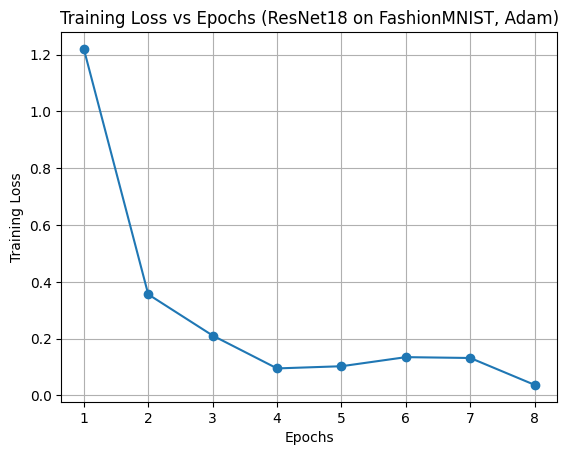

In [18]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(epochs, train_losses_fashion, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Training Loss")
plt.title("Training Loss vs Epochs (ResNet18 on FashionMNIST, Adam)")
plt.grid(True)
plt.show()


Experiment 2

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms
from torch.utils.data import DataLoader, Subset
import time
import pandas as pd
from torchvision.models import resnet18, resnet34, resnet50
from fvcore.nn import FlopCountAnalysis


In [ ]:
device = torch.device("cpu")   # change to "cuda" later
print("Using device:", device)


Using device: cpu


In [ ]:
transform = transforms.ToTensor()

train_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=True, download=True, transform=transform
)

test_dataset = torchvision.datasets.FashionMNIST(
    root="./data", train=False, download=True, transform=transform
)


100%|██████████| 26.4M/26.4M [00:00<00:00, 120MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 5.27MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 67.7MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 26.7MB/s]


In [ ]:
train_subset = Subset(train_dataset, range(10000))  # 10k samples
test_subset = Subset(test_dataset, range(2000))     # 2k samples

train_loader = DataLoader(train_subset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=16, shuffle=False)


In [ ]:
def train_model(model, loader, optimizer, criterion, device, epochs=1):
    model.train()
    start_time = time.time()

    for epoch in range(epochs):
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

    end_time = time.time()
    return (end_time - start_time) * 1000  # ms


In [ ]:
def test_model(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total


In [ ]:
def compute_flops(model):
    model.eval()
    dummy_input = torch.randn(1, 1, 28, 28).to(device)
    flops = FlopCountAnalysis(model, dummy_input).total()
    return flops


In [ ]:
models_dict = {
    "ResNet18": resnet18(num_classes=10),

    "ResNet50": resnet50(num_classes=10)
}

for model in models_dict.values():
    model.conv1 = nn.Conv2d(
        1, 64, kernel_size=7, stride=2, padding=3, bias=False
    )


In [ ]:
optimizers_dict = {
    "SGD": optim.SGD,
    "Adam": optim.Adam
}


In [ ]:
results = []

for opt_name, opt_class in optimizers_dict.items():
    for model_name, model in models_dict.items():

        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = opt_class(model.parameters(), lr=0.001)

        print(f"Training {model_name} on {device} with {opt_name}")

        train_time = train_model(
            model, train_loader, optimizer, criterion, device, epochs=1
        )

        accuracy = test_model(model, test_loader, device)

        flops = compute_flops(model)

        results.append({
            "Compute": device.type.upper(),
            "Batch Size": 16,
            "Optimizer": opt_name,
            "Learning Rate": 0.001,
            "Model": model_name,
            "Accuracy (%)": round(accuracy, 2),
            "Train Time (ms)": round(train_time, 2),
            "FLOPs": flops
        })


Training ResNet18 on cpu with SGD


Training ResNet50 on cpu with SGD


Training ResNet18 on cpu with Adam


Training ResNet50 on cpu with Adam


In [ ]:
df = pd.DataFrame(results)
df


,Compute,Batch Size,Optimizer,Learning Rate,Model,Accuracy (%),Train Time (ms),FLOPs
0,CPU,16,SGD,0.001,ResNet18,80.35,161201.66,33097472
1,CPU,16,SGD,0.001,ResNet50,62.20,352667.72,78353152
2,CPU,16,Adam,0.001,ResNet18,79.85,219992.64,33097472
3,CPU,16,Adam,0.001,ResNet50,61.70,456093.67,78353152


In [ ]:
device = torch.device("cuda")   # change to "cuda" later
print("Using device:", device)

Using device: cuda


In [ ]:
results = []

for opt_name, opt_class in optimizers_dict.items():
    for model_name, model in models_dict.items():

        model = model.to(device)
        criterion = nn.CrossEntropyLoss()
        optimizer = opt_class(model.parameters(), lr=0.001)

        print(f"Training {model_name} on {device} with {opt_name}")

        train_time = train_model(
            model, train_loader, optimizer, criterion, device, epochs=1
        )

        accuracy = test_model(model, test_loader, device)

        flops = compute_flops(model)

        results.append({
            "Compute": device.type.upper(),
            "Batch Size": 16,
            "Optimizer": opt_name,
            "Learning Rate": 0.001,
            "Model": model_name,
            "Accuracy (%)": round(accuracy, 2),
            "Train Time (ms)": round(train_time, 2),
            "FLOPs": flops
        })


Training ResNet18 on cuda with SGD


Training ResNet50 on cuda with SGD


Training ResNet18 on cuda with Adam


Training ResNet50 on cuda with Adam


In [ ]:
df = pd.DataFrame(results)
df

,Compute,Batch Size,Optimizer,Learning Rate,Model,Accuracy (%),Train Time (ms),FLOPs
0,CUDA,16,SGD,0.001,ResNet18,78.55,7872.07,33097472
1,CUDA,16,SGD,0.001,ResNet50,61.00,18305.87,78353152
2,CUDA,16,Adam,0.001,ResNet18,77.00,9293.69,33097472
3,CUDA,16,Adam,0.001,ResNet50,62.40,17419.21,78353152
